In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Order_Data_meriskill.csv", low_memory=False)

df.head()



,OrderID,Region,Country,CustID,Customer_Name,ProductSKU,Product_Category,OrderLineItem,OrderQuantity,ProductCost,ProductPrice,OrderDate,AcquisitionSource,TransactionID,Fraud,PaymentMethod,CardType,Gender
0,SO45080,Northwest,United States,14657,JOHN THOMAS,BK-R50B-58,Plants,1,1.0,413.1463,699.0982,01-01-2020,Meta-ads\r,I4127227587819694,False,CREDITCARD,DISCOVER,M
1,SO45079,Southwest,United States,29255,KYLE WASHINGTON,BK-R93R-48,Plants,1,1.0,2171.2942,3578.27,01-01-2020,Google-ads\r,E9525730529761877,False,CREDITCARD,MC,M
2,SO45082,Australia,Australia,11455,ROSS SANZ,BK-M82B-44,Plants,1,1.0,1898.0944,3374.99,01-01-2020,Google-ads\r,Z6376643485803420,False,CREDITCARD,VISA,M
3,SO45081,Canada,Canada,26782,SETH LEWIS,BK-R50B-44,Plants,1,1.0,413.1463,699.0982,01-01-2020,Google-ads\r,R8609290025411138,False,CREDITCARD,VISA,M
4,SO45083,United Kingdom,United Kingdom,14947,ALEJANDRO CHEN,BK-R93R-48,Plants,1,1.0,2171.2942,3578.27,02-01-2020,Meta-ads\r,Y9572700698484288,False,CREDITCARD,VISA,M


In [5]:
# Convert columns to numeric safely
def to_number(x):
    if pd.isna(x): return np.nan
    x = str(x).replace("£","").replace("$","").replace(",","").strip()
    try: return float(x)
    except: return np.nan

df["ProductPrice"] = df["ProductPrice"].apply(to_number)
df["ProductCost"]  = df["ProductCost"].apply(to_number)
df["OrderQuantity"] = pd.to_numeric(df["OrderQuantity"], errors="coerce")


In [6]:
import numpy as np
import pandas as pd

# --- Diagnose current types (optional but helpful)
print(df.dtypes)          # see which columns are "object" (text)
print(df.columns.tolist())  # confirm exact column names

# --- Helper: convert messy currency/number text -> float
def to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # remove common currency symbols and thousand separators
    s = s.replace("£","").replace("$","").replace(",","").strip()
    # remove any stray non-numeric characters (keeps digits, dot, minus)
    s = pd.Series([s]).str.replace(r"[^0-9\.\-]", "", regex=True).iloc[0]
    # empty string -> NaN
    if s == "" or s == "." or s == "-":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan

# --- Make sure the three key columns are numeric
for col in ["ProductPrice", "ProductCost", "OrderQuantity"]:
    # If your file uses different names, adjust here accordingly
    df[col] = df[col].apply(to_num)

# (Optional) sanity check
print(df[["ProductPrice","ProductCost","OrderQuantity"]].head())

# --- STEP 3: Compute metrics safely
df["Revenue"] = df["ProductPrice"] * df["OrderQuantity"]
df["Cost"]    = df["ProductCost"]  * df["OrderQuantity"]
df["Margin"]  = df["Revenue"] - df["Cost"]

# Quick preview to confirm it worked
df[["OrderID","ProductPrice","OrderQuantity","Revenue","Cost","Margin"]].head()

OrderID               object
Region                object
Country               object
CustID                object
Customer_Name         object
ProductSKU            object
Product_Category      object
OrderLineItem          int64
OrderQuantity        float64
ProductCost          float64
ProductPrice         float64
OrderDate             object
AcquisitionSource     object
TransactionID         object
Fraud                 object
PaymentMethod         object
CardType              object
Gender                object
dtype: object
['OrderID', 'Region', 'Country', 'CustID', 'Customer_Name', 'ProductSKU', 'Product_Category', 'OrderLineItem', 'OrderQuantity', 'ProductCost', 'ProductPrice', 'OrderDate', 'AcquisitionSource', 'TransactionID', 'Fraud', 'PaymentMethod', 'CardType', 'Gender']
   ProductPrice  ProductCost  OrderQuantity
0      699.0982     413.1463            1.0
1     3578.2700    2171.2942            1.0
2     3374.9900    1898.0944            1.0
3      699.0982     413.1463  

,OrderID,ProductPrice,OrderQuantity,Revenue,Cost,Margin
0,SO45080,699.0982,1.0,699.0982,413.1463,285.9519
1,SO45079,3578.2700,1.0,3578.2700,2171.2942,1406.9758
2,SO45082,3374.9900,1.0,3374.9900,1898.0944,1476.8956
3,SO45081,699.0982,1.0,699.0982,413.1463,285.9519
4,SO45083,3578.2700,1.0,3578.2700,2171.2942,1406.9758


In [7]:
#Group by campaign / acquisition source
campaign = df.groupby("AcquisitionSource").agg(
    Orders=("OrderID", "nunique"),
    Customers=("CustID", "nunique"),
    Revenue=("Revenue", "sum"),
    Cost=("Cost", "sum"),
    Margin=("Margin", "sum"),
    Avg_Order_Value=("Revenue", lambda x: x.sum() / len(x))
).reset_index()

campaign["Margin_%"] = (campaign["Margin"] / campaign["Revenue"]) * 100
campaign.sort_values("Margin", ascending=False)

,AcquisitionSource,Orders,Customers,Revenue,Cost,Margin,Avg_Order_Value,Margin_%
0,Google-ads\r,23047,16658,1.984020e+07,1.151215e+07,8.328057e+06,444.359425,41.975662
1,Meta-ads\r,5134,4731,2.572408e+06,1.493116e+06,1.079291e+06,457.886763,41.956466
2,Yt-Campaign\r,5161,4756,2.478366e+06,1.438438e+06,1.039928e+06,439.270871,41.960238


) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


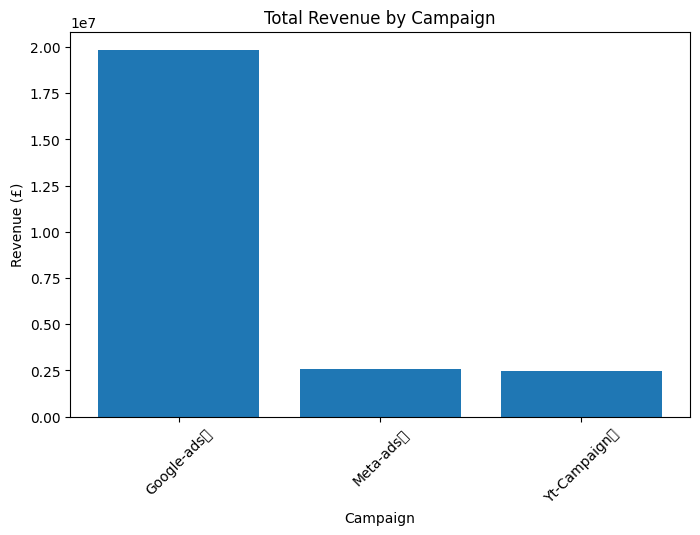

In [8]:
#Create charts

import matplotlib.pyplot as plt

# --- Bar chart: revenue per campaign
plt.figure(figsize=(8,5))
plt.bar(campaign["AcquisitionSource"], campaign["Revenue"])
plt.title("Total Revenue by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.show()

In [9]:
#quick score to choose your single campaign

campaign["Score"] = campaign["Margin"] / campaign["Revenue"].max()
best = campaign.sort_values("Score", ascending=False).head(1)
best

,AcquisitionSource,Orders,Customers,Revenue,Cost,Margin,Avg_Order_Value,Margin_%,Score
0,Google-ads\r,23047,16658,1.984020e+07,1.151215e+07,8.328057e+06,444.359425,41.975662,0.419757


In [10]:
fraud_rate = df.groupby("AcquisitionSource")["Fraud"].apply(lambda x: (x=="YES").mean()*100)
campaign = campaign.merge(fraud_rate, on="AcquisitionSource", how="left")
campaign.rename(columns={"Fraud":"Fraud_Rate_%"} , inplace=True)
campaign

,AcquisitionSource,Orders,Customers,Revenue,Cost,Margin,Avg_Order_Value,Margin_%,Score,Fraud_Rate_%
0,Google-ads\r,23047,16658,1.984020e+07,1.151215e+07,8.328057e+06,444.359425,41.975662,0.419757,0.0
1,Meta-ads\r,5134,4731,2.572408e+06,1.493116e+06,1.079291e+06,457.886763,41.956466,0.054399,0.0
2,Yt-Campaign\r,5161,4756,2.478366e+06,1.438438e+06,1.039928e+06,439.270871,41.960238,0.052415,0.0


) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


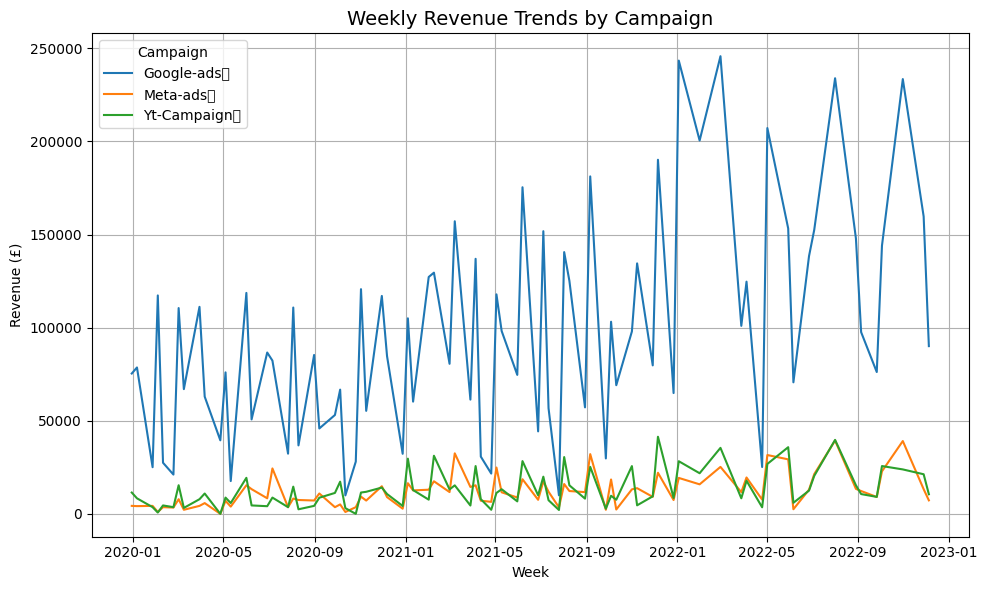

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure OrderDate is in datetime format
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")

# Drop rows where OrderDate is missing
df = df.dropna(subset=["OrderDate"])

# Extract the week start (e.g. every Monday)
df["Week"] = df["OrderDate"].dt.to_period("W").apply(lambda r: r.start_time)

# Group by week and campaign
weekly = (
    df.groupby(["Week", "AcquisitionSource"])
      .agg(Revenue=("Revenue", "sum"))
      .reset_index()
)

# Pivot for plotting
weekly_pivot = weekly.pivot(index="Week", columns="AcquisitionSource", values="Revenue").fillna(0)

# --- Plot
plt.figure(figsize=(10,6))
for campaign in weekly_pivot.columns:
    plt.plot(weekly_pivot.index, weekly_pivot[campaign], label=campaign)

plt.title("Weekly Revenue Trends by Campaign", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Revenue (£)")
plt.legend(title="Campaign")
plt.grid(True)
plt.tight_layout()
plt.show()

) missing from font(s) DejaVu Sans.
  plt.tight_layout()
) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


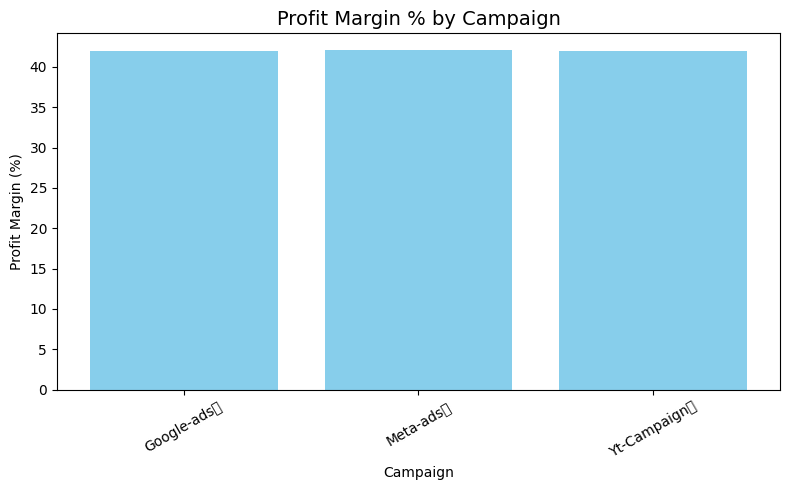

In [14]:
# Calculate total margin percentage per campaign
margin_summary = (
    df.groupby("AcquisitionSource")
      .agg(Revenue=("Revenue","sum"), Margin=("Margin","sum"))
      .reset_index()
)
margin_summary["Margin_%"] = (margin_summary["Margin"] / margin_summary["Revenue"]) * 100

# --- Plot
plt.figure(figsize=(8,5))
plt.bar(margin_summary["AcquisitionSource"], margin_summary["Margin_%"], color="skyblue")
plt.title("Profit Margin % by Campaign", fontsize=14)
plt.xlabel("Campaign")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
# Create a campaign summary with unique customers and orders
campaign_summary = (
    df.groupby("AcquisitionSource")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustID", "nunique"),
          Revenue=("Revenue", "sum"),
          Cost=("Cost", "sum"),
          Margin=("Margin", "sum")
      )
      .reset_index()
)

# Compute additional KPIs
campaign_summary["AOV"] = campaign_summary["Revenue"] / campaign_summary["Orders"]
campaign_summary["Margin_%"] = (campaign_summary["Margin"] / campaign_summary["Revenue"]) * 100

# Show summary
campaign_summary

,AcquisitionSource,Orders,Customers,Revenue,Cost,Margin,AOV,Margin_%
0,Google-ads\r,9118,7881,7.803858e+06,4.527809e+06,3.276049e+06,855.873858,41.979860
1,Meta-ads\r,2024,1954,9.712501e+05,5.628851e+05,4.083650e+05,479.866661,42.045297
2,Yt-Campaign\r,2092,2017,1.047955e+06,6.078927e+05,4.400624e+05,500.934597,41.992487


In [20]:
# Add hypothetical spend for each campaign (just to test)
spend_data = {
    "Google Ads": 50000,
    "Meta Ads": 40000,
    "YouTube": 30000
}

campaign_summary["Spend"] = campaign_summary["AcquisitionSource"].map(spend_data)
campaign_summary["CAC"] = campaign_summary["Spend"] / campaign_summary["Customers"]

campaign_summary


,AcquisitionSource,Orders,Customers,Revenue,Cost,Margin,AOV,Margin_%,Spend,CAC
0,Google-ads\r,9118,7881,7.803858e+06,4.527809e+06,3.276049e+06,855.873858,41.979860,NaN,NaN
1,Meta-ads\r,2024,1954,9.712501e+05,5.628851e+05,4.083650e+05,479.866661,42.045297,NaN,NaN
2,Yt-Campaign\r,2092,2017,1.047955e+06,6.078927e+05,4.400624e+05,500.934597,41.992487,NaN,NaN


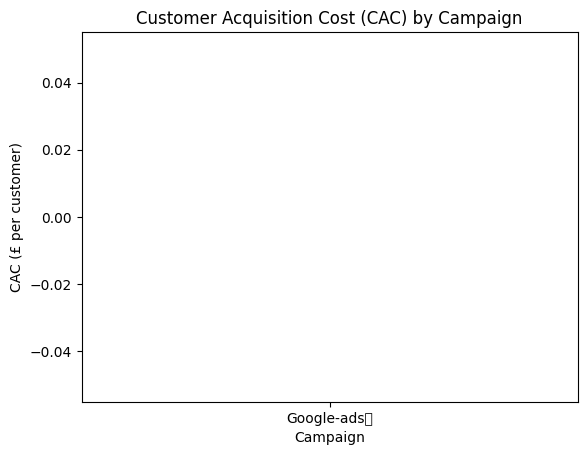

In [24]:
import matplotlib.pyplot as plt

plt.bar(campaign_summary["AcquisitionSource"], campaign_summary["CAC"], color="teal")
plt.title("Customer Acquisition Cost (CAC) by Campaign")
plt.xlabel("Campaign")
plt.ylabel("CAC (£ per customer)")
plt.show()

In [26]:
# Check what campaign names look like
print("Unique AcquisitionSource values:")
print(df["AcquisitionSource"].astype(str).str.strip().value_counts())

# Show the current summary with all important columns
print("\nCampaign summary (top rows):")
print(campaign_summary[["AcquisitionSource","Orders","Customers","Revenue","Margin"]].head())

# If you've already added Spend/CAC:
if "Spend" in campaign_summary.columns:
    print("\nSpend/CAC preview:")
    print(campaign_summary[["AcquisitionSource","Spend","Customers","CAC"]])

Unique AcquisitionSource values:
AcquisitionSource
Google-ads     17748
Yt-Campaign     2297
Meta-ads        2176
Name: count, dtype: int64

Campaign summary (top rows):
  AcquisitionSource  Orders  Customers       Revenue        Margin
0      Google-ads\r    9118       7881  7.803858e+06  3.276049e+06
1        Meta-ads\r    2024       1954  9.712501e+05  4.083650e+05
2     Yt-Campaign\r    2092       2017  1.047955e+06  4.400624e+05

Spend/CAC preview:
  AcquisitionSource  Spend  Customers  CAC
0      Google-ads\r    NaN       7881  NaN
1        Meta-ads\r    NaN       1954  NaN
2     Yt-Campaign\r    NaN       2017  NaN


In [28]:
import numpy as np

# Normalize AcquisitionSource
df["AcquisitionSource"] = (
    df["AcquisitionSource"]
    .astype(str)
    .str.strip()
)

# Rebuild summary to use normalized names (optional but clean)
campaign_summary = (
    df.groupby("AcquisitionSource")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustID", "nunique"),
          Revenue=("Revenue", "sum"),
          Cost=("Cost", "sum"),
          Margin=("Margin", "sum")
      )
      .reset_index()
)

campaign_summary["AOV"] = campaign_summary["Revenue"] / campaign_summary["Orders"].replace(0, np.nan)
campaign_summary["Margin_%"] = (campaign_summary["Margin"] / campaign_summary["Revenue"].replace(0, np.nan)) * 100

# ---- Simulated spend: make sure KEYS MATCH your normalized names exactly
spend_data = {
    "Google Ads": 50000,
    "Meta Ads": 40000,
    "YouTube": 30000,
}

# Map spend; any campaign not in the dict will get NaN (we'll handle it)
campaign_summary["Spend"] = campaign_summary["AcquisitionSource"].map(spend_data)

# Compute CAC only where both Spend>0 and Customers>0
campaign_summary["CAC"] = np.where(
    (campaign_summary["Spend"].fillna(0) > 0) & (campaign_summary["Customers"] > 0),
    campaign_summary["Spend"] / campaign_summary["Customers"],
    np.nan
)

print(campaign_summary)

  AcquisitionSource  Orders  Customers       Revenue          Cost  \
0        Google-ads    9118       7881  7.803858e+06  4.527809e+06   
1          Meta-ads    2024       1954  9.712501e+05  5.628851e+05   
2       Yt-Campaign    2092       2017  1.047955e+06  6.078927e+05   

         Margin         AOV   Margin_%  Spend  CAC  
0  3.276049e+06  855.873858  41.979860    NaN  NaN  
1  4.083650e+05  479.866661  42.045297    NaN  NaN  
2  4.400624e+05  500.934597  41.992487    NaN  NaN  


In [30]:
import matplotlib.pyplot as plt

plot_df = campaign_summary.loc[campaign_summary["CAC"].notna() & (campaign_summary["CAC"] > 0)].copy()

if plot_df.empty:
    print("Nothing to plot: check Spend mapping and Customers>0.")
else:
    plt.figure(figsize=(8,5))
    plt.bar(plot_df["AcquisitionSource"], plot_df["CAC"])
    plt.title("Customer Acquisition Cost (CAC) by Campaign")
    plt.xlabel("Campaign")
    plt.ylabel("CAC (GBP per customer)")  # avoid £ if you saw font warnings
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

Nothing to plot: check Spend mapping and Customers>0.


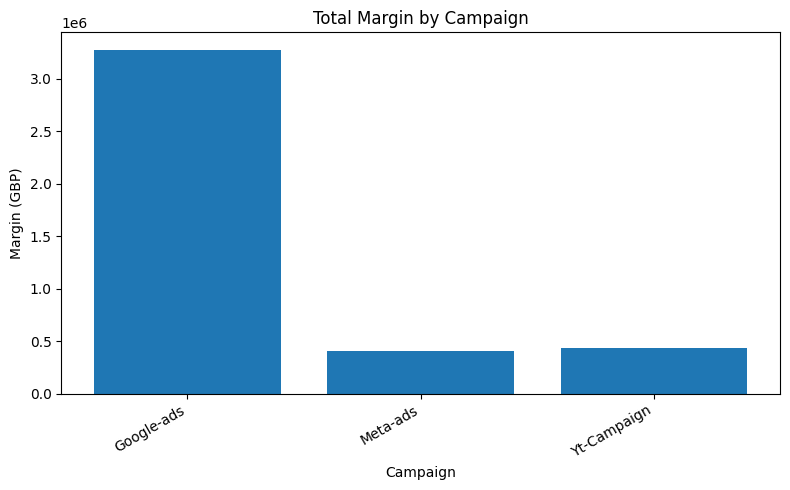

In [32]:
plt.figure(figsize=(8,5))
plt.bar(campaign_summary["AcquisitionSource"], campaign_summary["Margin"])
plt.title("Total Margin by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Margin (GBP)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [34]:
import numpy as np
import pandas as pd

# Clean AcquisitionSource so mapping works
df["AcquisitionSource"] = (
    df["AcquisitionSource"]
      .astype(str)
      .str.replace(r'[\r\n\t]', '', regex=True)  # remove \r \n \t
      .str.strip()
)

# Rebuild summary after cleaning
campaign_summary = (
    df.groupby("AcquisitionSource")
      .agg(
          Orders=("OrderID", "nunique"),
          Customers=("CustID", "nunique"),
          Revenue=("Revenue", "sum"),
          Cost=("Cost", "sum"),
          Margin=("Margin", "sum")
      )
      .reset_index()
)

campaign_summary["AOV"] = campaign_summary["Revenue"] / campaign_summary["Orders"].replace(0, np.nan)
campaign_summary["Margin_%"] = (campaign_summary["Margin"] / campaign_summary["Revenue"].replace(0, np.nan)) * 100

print("Cleaned labels:")
print(campaign_summary["AcquisitionSource"].tolist())

Cleaned labels:
['Google-ads', 'Meta-ads', 'Yt-Campaign']


In [36]:
spend_data = {
    "Google-ads": 50000,
    "Meta-ads": 40000,
    "Yt-Campaign": 30000
}

campaign_summary["Spend"] = campaign_summary["AcquisitionSource"].map(spend_data)

In [38]:
campaign_summary["CAC"] = np.where(
    (campaign_summary["Spend"].notna()) & (campaign_summary["Spend"] > 0) & (campaign_summary["Customers"] > 0),
    campaign_summary["Spend"] / campaign_summary["Customers"],
    np.nan
)

campaign_summary[["AcquisitionSource","Spend","Customers","CAC"]]

,AcquisitionSource,Spend,Customers,CAC
0,Google-ads,50000,7881,6.344373
1,Meta-ads,40000,1954,20.470829
2,Yt-Campaign,30000,2017,14.873575


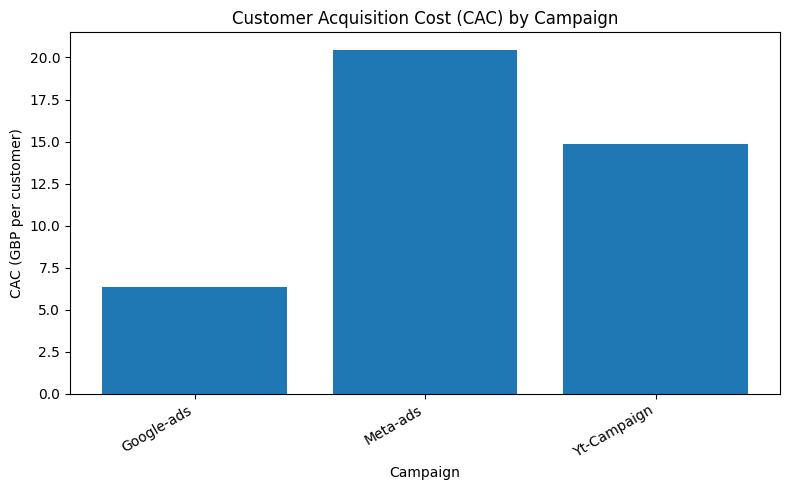

In [40]:
import matplotlib.pyplot as plt

plot_df = campaign_summary.loc[campaign_summary["CAC"].notna() & (campaign_summary["CAC"] > 0)].copy()

if plot_df.empty:
    print("Nothing to plot — check Spend mapping and Customers>0.")
else:
    plt.figure(figsize=(8,5))
    plt.bar(plot_df["AcquisitionSource"], plot_df["CAC"])
    plt.title("Customer Acquisition Cost (CAC) by Campaign")
    plt.xlabel("Campaign")
    plt.ylabel("CAC (GBP per customer)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

Predicted customers for £25,000 budget: 535


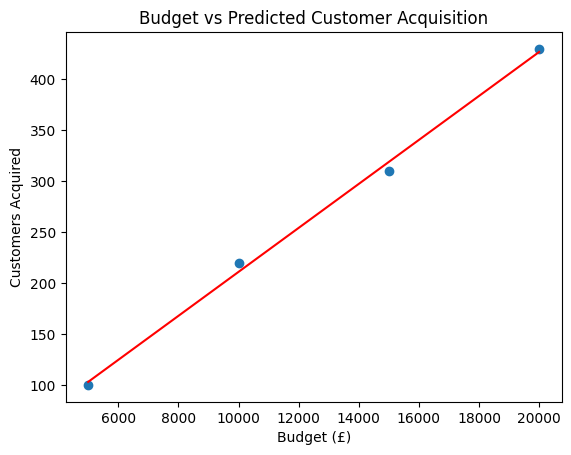

In [41]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Example only: budget vs customers
budget = np.array([5000, 10000, 15000, 20000]).reshape(-1,1)
customers = np.array([100, 220, 310, 430])

model = LinearRegression()
model.fit(budget, customers)

predicted = model.predict(np.array([[25000]]))
print(f"Predicted customers for £25,000 budget: {predicted[0]:.0f}")


plt.scatter(budget, customers)
plt.plot(budget, model.predict(budget), color='red')
plt.title("Budget vs Predicted Customer Acquisition")
plt.xlabel("Budget (£)")
plt.ylabel("Customers Acquired")
plt.show()